## Imports

In [1]:
import logging, warnings; logging.getLogger().setLevel(logging.ERROR);
warnings.filterwarnings("ignore")

import scanpy as sc
import scanpy.external as sce
import numpy as np
import pandas as pd
import re
from pathlib import Path 

import warnings, scipy.sparse as sp, matplotlib, matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.pyplot import rc_context
import matplotlib.font_manager
import matplotlib.lines as lines


pd.set_option('display.max_rows', 200)

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = 'Arial'
matplotlib.rc('font', size=12)

sc.settings.n_jobs=-1
sc.set_figure_params(dpi=80, dpi_save=300, color_map='Spectral_r', vector_friendly=True, transparent=True)
sc.settings.figdir = '../../1_outputs/0_figures'
sc.settings.verbosity = 1 # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()

%matplotlib inline 
%config InlineBackend.figure_format = 'retina'

In [2]:
# preset color palettes and color maps
user_defined_palette =  [ '#F6222E', '#16FF32', '#3283FE', '#FEAF16', '#BDCDFF', '#3B00FB', '#1CFFCE', '#C075A6', '#F8A19F', '#B5EFB5', '#FBE426', '#C4451C', 
                          '#2ED9FF', '#c1c119', '#8b0000', '#FE00FA', '#1CBE4F', '#1C8356', '#0e452b', '#AA0DFE', '#B5EFB5', '#325A9B', '#90AD1C']

user_defined_cmap_markers = LinearSegmentedColormap.from_list('mycmap', ["#E6E6FF", "#CCCCFF", "#B2B2FF", "#9999FF",  "#6666FF",   "#3333FF", "#0000FF"])
user_defined_cmap_degs = LinearSegmentedColormap.from_list('mycmap', ["#0000FF", "#3333FF", "#6666FF", "#9999FF", "#B2B2FF", "#CCCCFF", "#E6E6FF", "#E6FFE6", "#CCFFCC", "#B2FFB2", "#99FF99", "#66FF66", "#33FF33", "#00FF00"])

In [3]:
pwd

'/Users/mkaur/github/2_tff1/1_tecs/1_pyzone/0_notebooks/0_scRNA/1_annotation'

In [4]:
file_outputs = '../../../1_outputs/' 
h5ad = '../../../3_h5ad/'

In [5]:
## read in h5ad 

adata = sc.read_h5ad(h5ad + "5_fb.h5ad")
adata

AnnData object with n_obs × n_vars = 134 × 33594
    obs: 'sample', 'log10_original_total_counts', 'n_genes_by_counts', 'ribo_frac', 'mito_frac', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.5', 'leiden_0.6', 'leiden_0.7', 'leiden_0.8', 'leiden_0.9', 'leiden_1.0', 'leiden_1.1', 'leiden_1.2', 'leiden_1.3', 'leiden_1.4', 'leiden_1.5', 'cell_type'
    uns: 'cell_type_colors', 'leiden_0.1', 'leiden_0.1_colors', 'leiden_0.2', 'leiden_0.2_colors', 'leiden_0.3', 'leiden_0.3_colors', 'leiden_0.4', 'leiden_0.4_colors', 'leiden_0.5', 'leiden_0.5_colors', 'leiden_0.6', 'leiden_0.6_colors', 'leiden_0.7', 'leiden_0.7_colors', 'leiden_0.8', 'leiden_0.8_colors', 'leiden_0.9', 'leiden_0.9_colors', 'leiden_1.0', 'leiden_1.0_colors', 'leiden_1.1', 'leiden_1.1_colors', 'leiden_1.2', 'leiden_1.2_colors', 'leiden_1.3', 'leiden_1.3_colors', 'leiden_1.4', 'leiden_1.4_colors', 'leiden_1.5', 'leiden_1.5_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'sample_colors', 'umap'
    

## Rerun HVG, PCA, Harmony, UMAP

In [6]:
#sc.pp.highly_variable_genes(adata, n_top_genes=3000, n_bins=20, flavor='seurat',  inplace=True)

In [22]:
sc.tl.pca(adata, n_comps=2, svd_solver='arpack', random_state=42, use_highly_variable=False) #change use_highly_variable == True if you ran the block above

#### Harmony integrate the data if there are large batch effects

In [23]:
#sce.pp.harmony_integrate(adata, 'condition') #Usually you want to run based on replicates but you can also run based on other parameters

If you batch corrected, make sure to use the use_rep = 'X_pca_harmony' paremeter below

In [24]:
sc.pp.neighbors(adata, n_neighbors=10, random_state=42, use_rep='X_pca')  # Change use_rep == X_pca_harmony if you ran the block above

In [25]:
sc.tl.umap(adata, random_state=42)#, min_dist = 0.3, spread = 1.1)

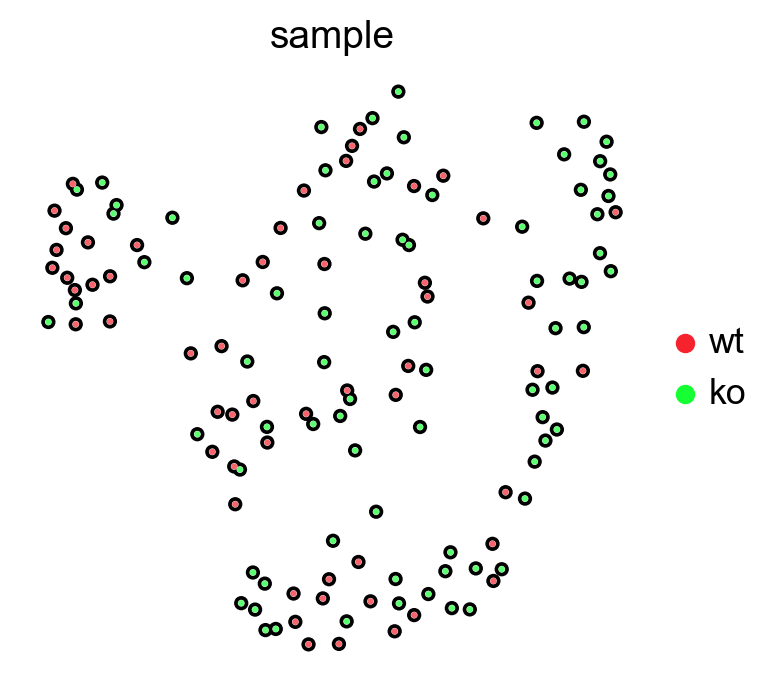

In [26]:
sc.set_figure_params(dpi=100, dpi_save=300, color_map='viridis', vector_friendly=False, transparent=True)
sc.pl.umap(
    adata, 
    color=['sample'],   
    color_map='Spectral_r', 
    use_raw=False,
    ncols=5,
    wspace = 0.5,
    outline_width=[0.6, 0.05],
    size=20,
    frameon=False,
    add_outline=True,
    sort_order = False
)

# Annotations

In [27]:
capsFB_sign = ['Pi16',	'Timp2',	'Fn1',	'Opcml',	'Cd248',	'Mfap5',	'Anxa3',	'Pcolce2',	'Ackr3',	'Fndc1',	'Igfbp6',	'Sema3c',	'Clec3b',	'Creb5',	'Smpd3',	'Tmem100',	'Adgrd1',	'Ly6c1',	'Pcsk6',	'Nid1']
intFB_sign = ['Smoc2',	'Gpx3',	'Penk',	'Igf1',	'Gas1',	'Inmt',	'Pcolce',	'Lrp1',	'Itm2a',	'Gdf10',	'Rbp1',	'Fbln1',	'Sfrp1',	'Slit3',	'Svep1',	'Auts2',	'Lpl',	'Celf2',	'Serpinf1',	'Il11ra1']
medFB_sign = ['Csmd1',	'Serpine2',	'Enpp2',	'Ptn',	'Tmem176b',	'Tmem176a',	'B2m',	'Ccl19',	'Igfbp7',	'Apod',	'Bgn',	'H2-D1',	'Des',	'Ltc4s',	'Lhfp',	'Ifitm1',	'Cd9',	'Apoe',	'Lsamp',	'Ly6e']

In [28]:
sc.tl.score_genes(adata, capsFB_sign , score_name='capsFB', use_raw=False)
sc.tl.score_genes(adata, intFB_sign , score_name='intFB', use_raw=False)
sc.tl.score_genes(adata, medFB_sign , score_name='medFB', use_raw=False)

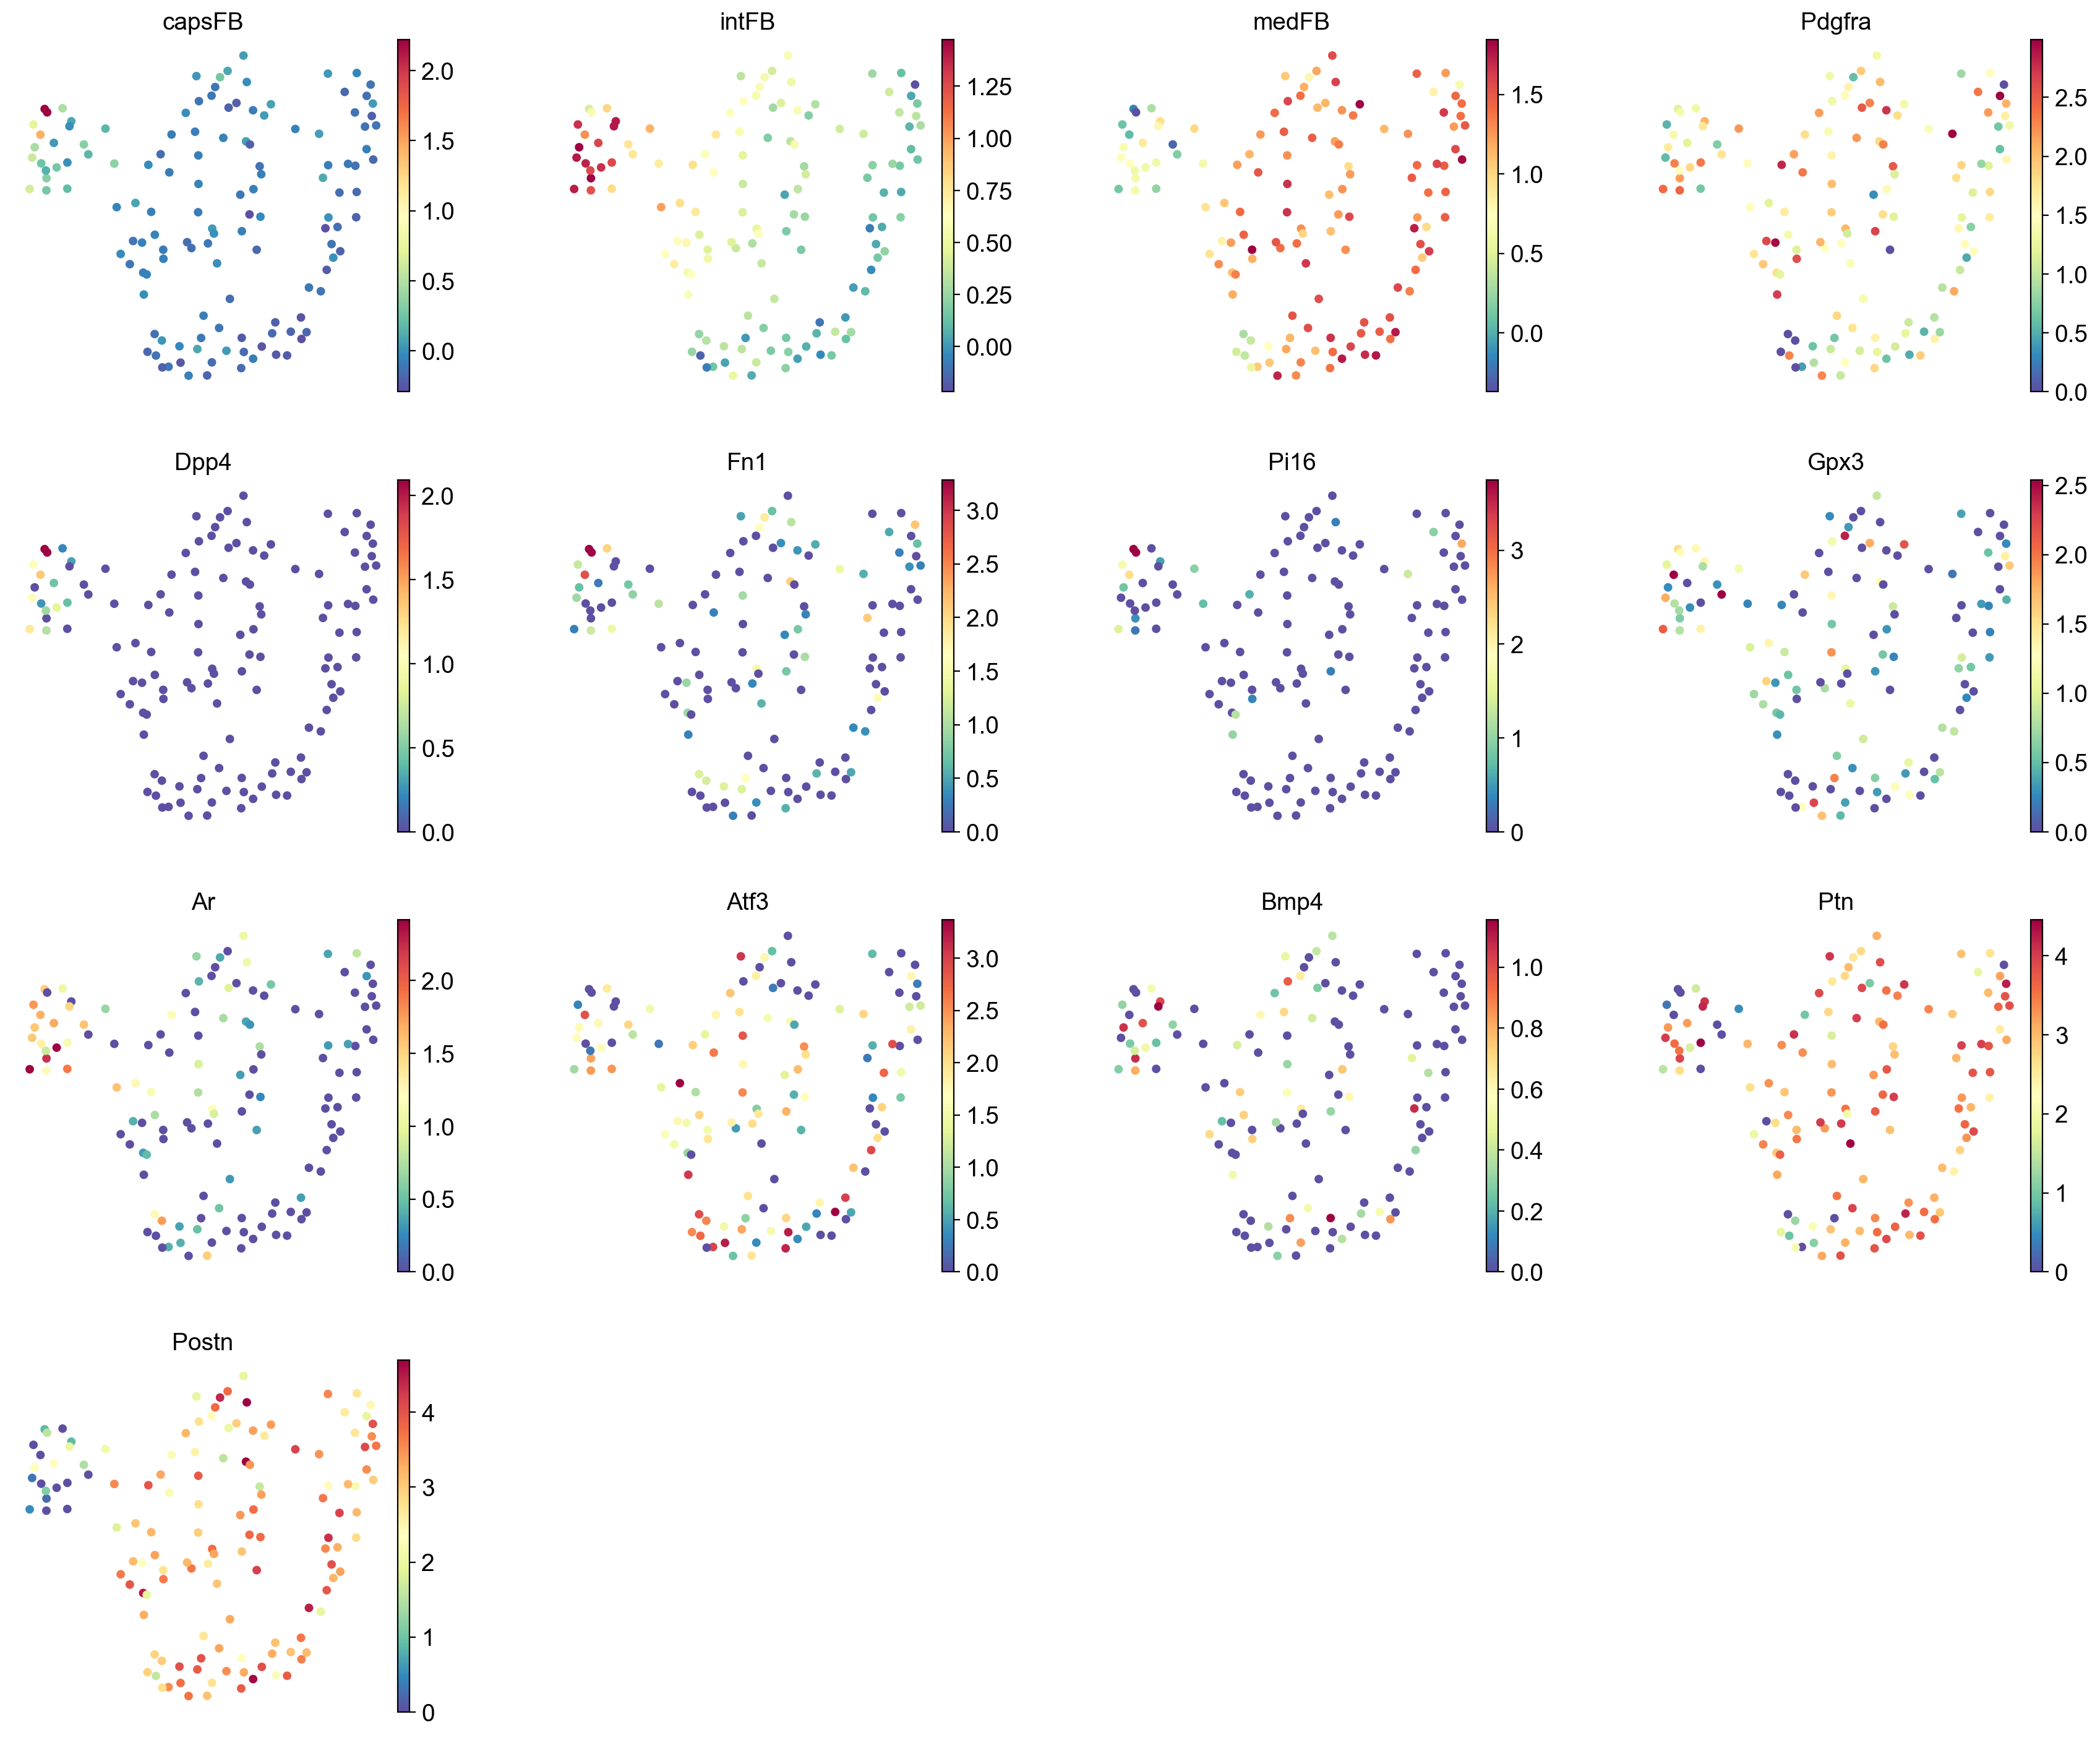

In [29]:
sc.set_figure_params(dpi=100, dpi_save=300, color_map='viridis', vector_friendly=True, transparent=True)
sc.pl.umap(
    adata, 
    color=[

        'capsFB', 'intFB', 'medFB', "Pdgfra", "Dpp4", "Fn1", "Pi16", "Gpx3", "Ar", "Atf3", "Bmp4", "Ptn", "Postn",

        ],  
    color_map='Spectral_r', 
    use_raw=False,
    ncols=4,
    wspace = 0.3,
    outline_width=[0.6, 0.05],
    vmax='p99',
    size=100,
    frameon=False,
    #add_outline=True,
    sort_order = False,
)

In [30]:
#0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 
#1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0

for resolution_parameter in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
    sc.tl.leiden(adata, resolution=resolution_parameter, random_state=42, key_added='leiden_'+str(resolution_parameter))

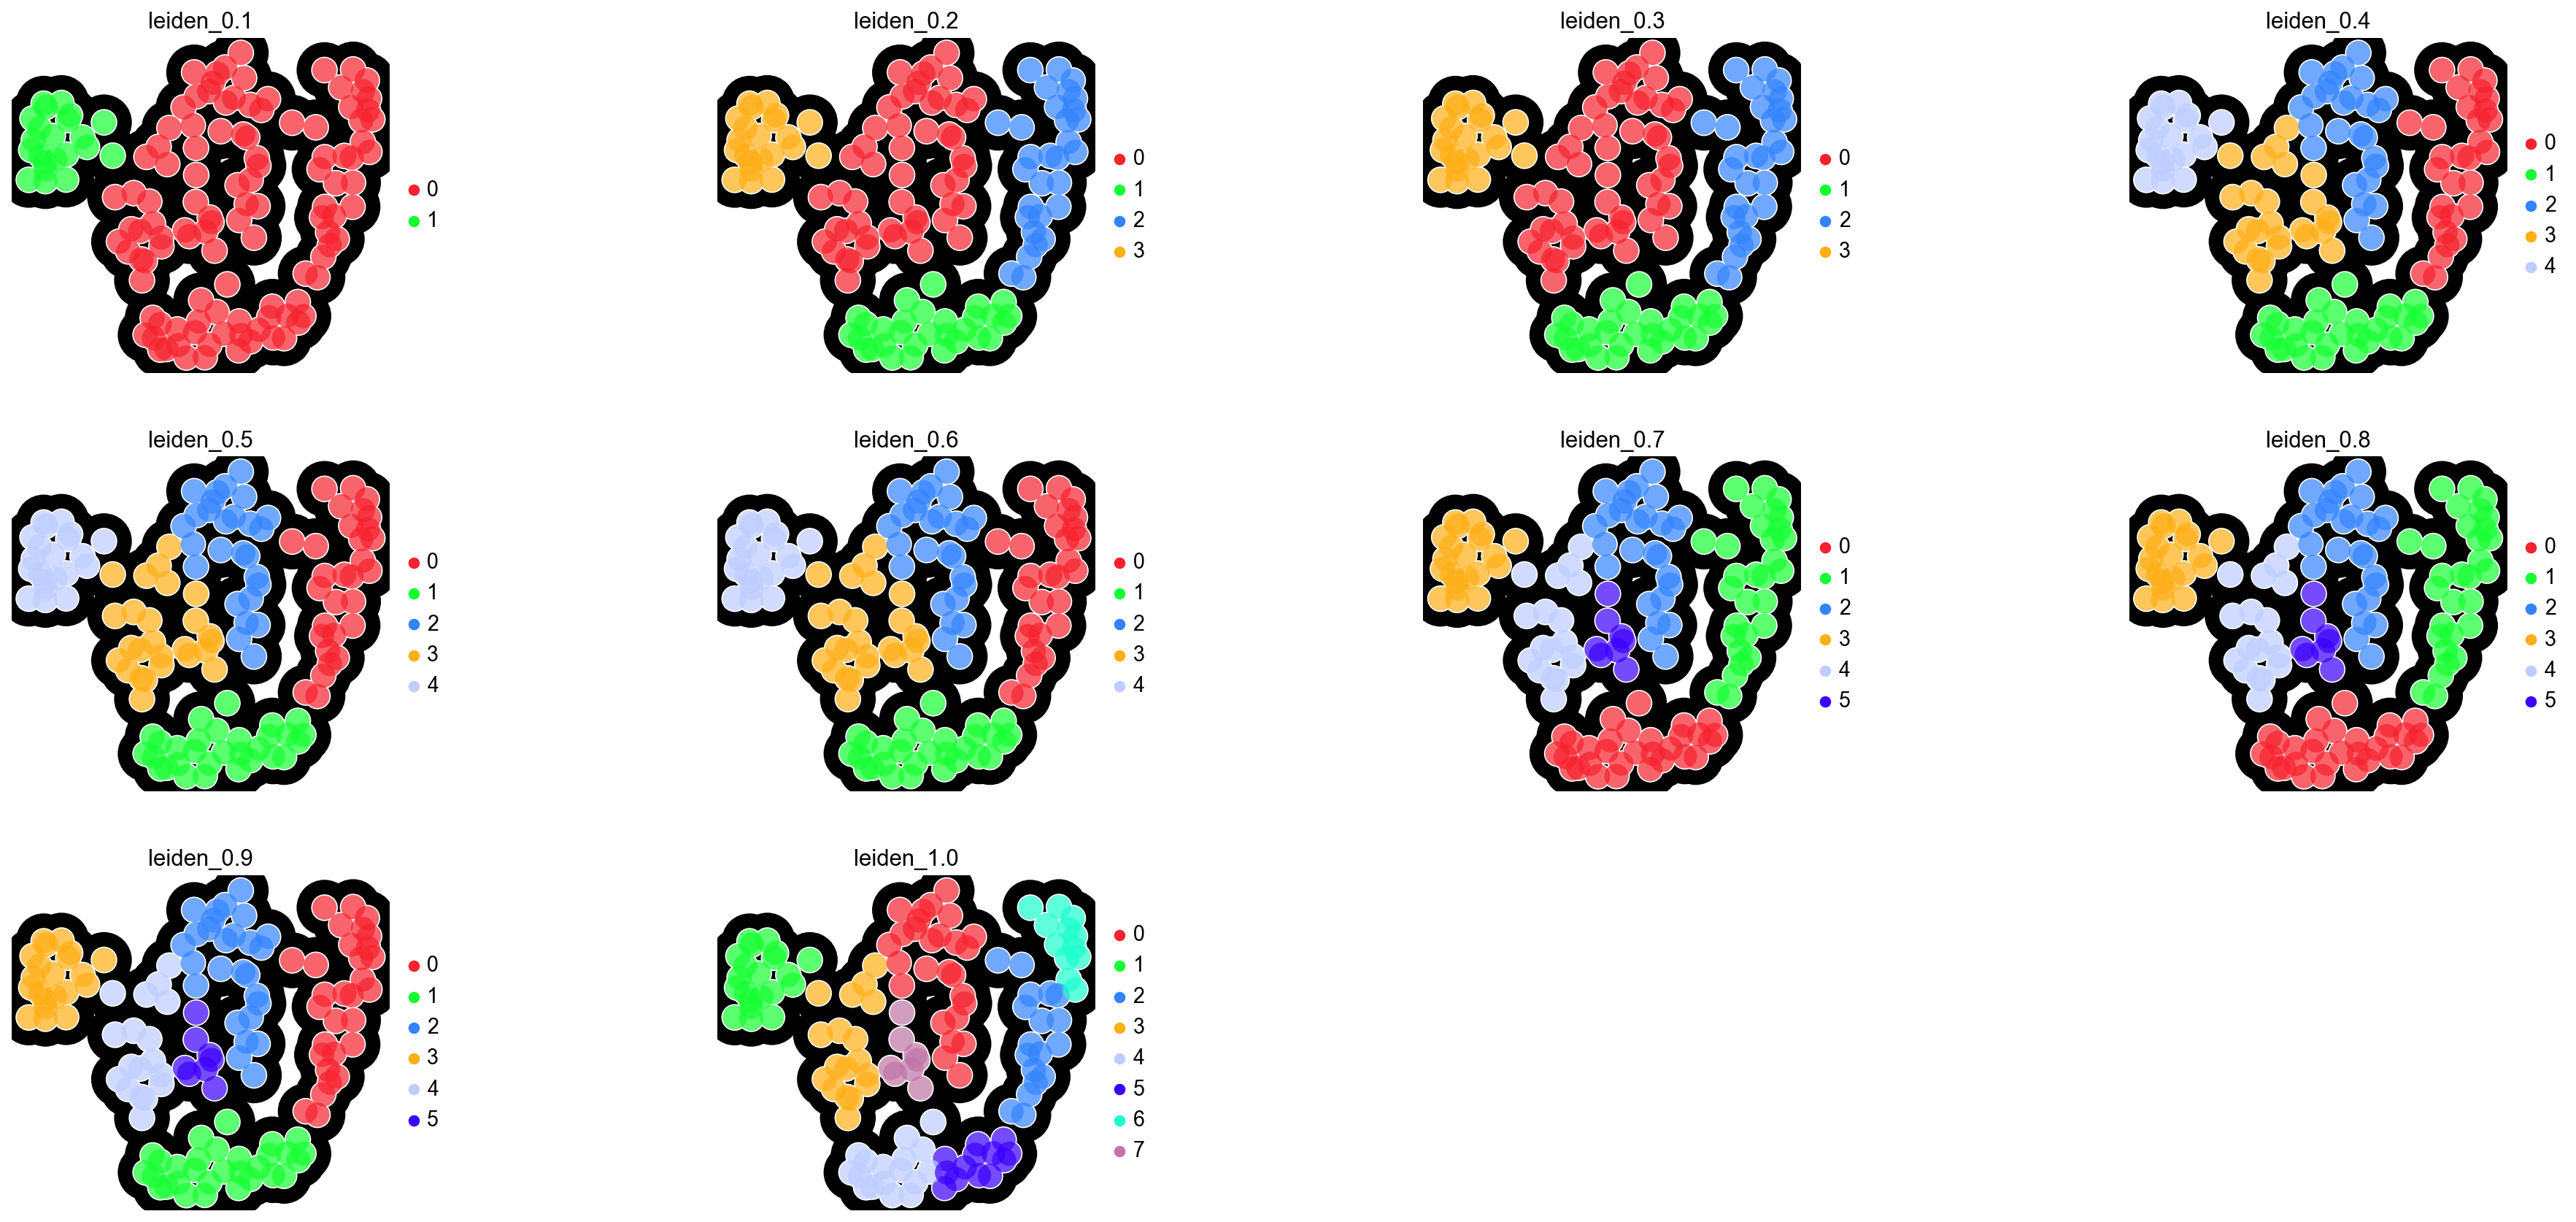

In [31]:
#'leiden_0.1', 'leiden_0.2', 'leiden_0.3','leiden_0.4', 'leiden_0.5', 'leiden_0.6', 'leiden_0.8', 'leiden_0.9', 'leiden_1.0',
#'leiden_1.1', 'leiden_1.2', 'leiden_1.3','leiden_1.4', 'leiden_1.5', 'leiden_1.6', 'leiden_1.7', 'leiden_1.8', 'leiden_1.9', 'leiden_2.0'

sc.set_figure_params(dpi=80, dpi_save=300, color_map='viridis', vector_friendly=True, transparent=True)
sc.pl.umap(
    adata, 
    color=[
        'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.5',
        'leiden_0.6', 'leiden_0.7', 'leiden_0.8', 'leiden_0.9', 'leiden_1.0',
           ], 
    palette=user_defined_palette,  
    color_map='Spectral_r', 
    use_raw=False,
    ncols=4,
    wspace = 0.7,
    outline_width=[0.6, 0.05],
    #size=35,
    frameon=False,
    add_outline=True,
    sort_order = False
)

In [32]:
sc.tl.rank_genes_groups(adata, 
                        groupby='leiden_0.1',  # Change the Leiden clustering
                        method='wilcoxon', 
                        use_raw=False)

result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names

df = pd.DataFrame(
    {group + '_' + key[:1]: result[key][group]
    for group in groups for key in ['names']}).head(150)

df.to_csv(file_outputs + '2_fb_leiden0.1.csv', index = False)

df.head(25)

,0_n,1_n
0,Ctsc,Ogn
1,Serpine2,Slit3
2,Itga1,Celf2
3,Postn,Aldh1a1
4,Csmd1,Col14a1
5,Des,Lrp1
6,4833422C13Rik,Slc4a4
7,Col6a4,Cdon
8,Rai14,Adamts5
9,Meox1,Slc8a1


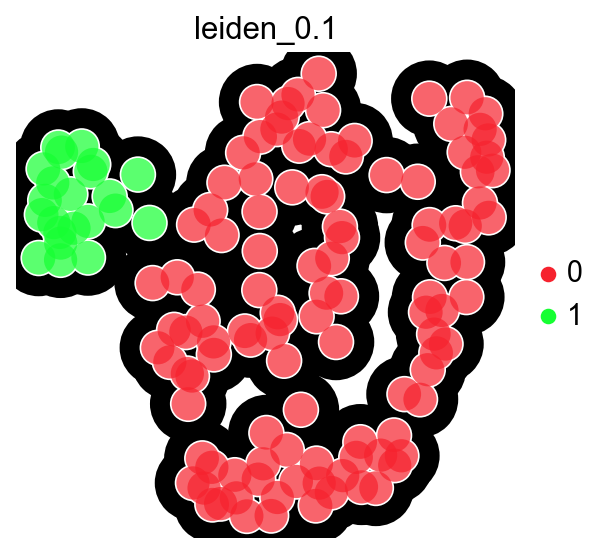

In [33]:
#'leiden_0.1', 'leiden_0.2', 'leiden_0.3','leiden_0.4', 'leiden_0.5', 'leiden_0.6', 'leiden_0.8', 'leiden_0.9', 'leiden_1.0',
#'leiden_1.1', 'leiden_1.2', 'leiden_1.3','leiden_1.4', 'leiden_1.5', 'leiden_1.6', 'leiden_1.7', 'leiden_1.8', 'leiden_1.9', 'leiden_2.0'

sc.set_figure_params(dpi=80, dpi_save=300, color_map='viridis', vector_friendly=True, transparent=True)
sc.pl.umap(
    adata, 
    color=[
        'leiden_0.1',
           ], 
    palette=user_defined_palette,  
    color_map='Spectral_r', 
    use_raw=False,
    ncols=4,
    wspace = 0.7,
    outline_width=[0.6, 0.05],
    #size=35,
    frameon=False,
    add_outline=True,
    sort_order = False
)

In [34]:
cell_type_groups = {
    'capsFB/intFB' : ['0', '3'], 
    'medFB' : ['1', '2']
    # add more as needed
}

cluster_to_cell_type = {cluster: cell_type for cell_type, clusters in cell_type_groups.items() for cluster in clusters}

In [35]:
adata.obs['cell_type'] = adata.obs['leiden_0.1'].map(cluster_to_cell_type) #Add Leiden Cluster

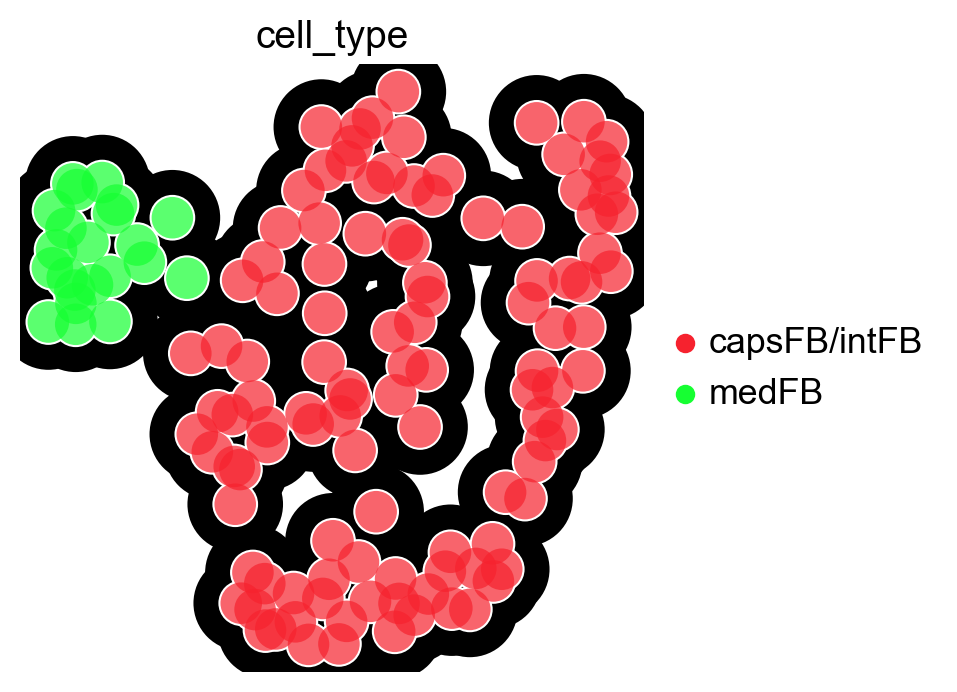

In [36]:
sc.set_figure_params(dpi=100, dpi_save=300, color_map='viridis', vector_friendly=False, transparent=True)
sc.pl.umap(
    adata, 
    color=[
        'cell_type', 
          ],
    palette=user_defined_palette,  
    color_map='Spectral_r', 
    use_raw=False,
    ncols=5,
    wspace = 0.3,
    outline_width=[0.6, 0.05],
    frameon=False,
    add_outline=True,
    sort_order = False, 
)

In [37]:
adata.write_h5ad(h5ad + '5_fb.h5ad')